# CMPE-258 Option 1 — Face mask detection (Kaggle andrewmvd)

**Goal:** Train a 2D object detector with a **baseline** run, then improve it using **(1) training strategy** and **(2) model architecture / scale**.

**Dataset:** [Face Mask Detection (andrewmvd)](https://www.kaggle.com/datasets/andrewmvd/face-mask-detection) — 3 classes, Pascal VOC XML boxes.


## Why Ultralytics YOLO here (vs MMDetection)

| | **Ultralytics YOLOv8** | **MMDetection** |
|---|---|---|
| **Setup on Colab** | Usually minutes; `pip install ultralytics` | Heavier install; more config files |
| **Architecture changes** | Mostly **model scale** (`n/s/m/l/x`) and YAML variants; still valid “architecture via configuration” | **Deeper swaps**: ResNet vs Swin backbone, different necks/heads, many papers reproduced |
| **Training strategy** | One `train()` call with many knobs (aug, optimizer, scheduler, imgsz, batch) | Same idea, but scattered across config Python/YAML |
| **Best when** | You want reliable end-to-end training + metrics quickly (typical course timeline) | You explicitly need fancy backbone/neck ablations |

**Our plan:** Use YOLOv8 on Colab. **Baseline** = small model + default-ish training. **Improvement 1 (strategy)** = stronger schedule + augmentations + optimizer. **Improvement 2 (architecture)** = move from `yolov8n` → `yolov8s` (same task, larger capacity).

## 1) Install dependencies

In [2]:
%pip install -q ultralytics kaggle opencv-python-headless lxml tqdm pyyaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 67.2 MB/s eta 0:00:00


In [2]:
from google.colab import files
files.upload()  # select kaggle.json
!mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


## 3) Download and unzip the dataset

This uses the official Kaggle slug for **andrewmvd/face-mask-detection**.

In [ ]:
!kaggle datasets download -d andrewmvd/face-mask-detection -p /content -f face-mask-detection.zip
!unzip -q -o /content/face-mask-detection.zip -d /content/face_mask_raw

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/face-mask-detection
License(s): CC0-1.0
404 Client Error: Not Found for url: https://api.kaggle.com/v1/datasets.DatasetApiService/DownloadDataset
unzip:  cannot find or open /content/face-mask-detection.zip, /content/face-mask-detection.zip.zip or /content/face-mask-detection.zip.ZIP.


In [ ]:
!ls -la ~/.kaggle
!python -m kaggle --version
!kaggle datasets list -s "face mask detection" | head

total 16
drwxr-xr-x 2 root root 4096 Apr 14 06:53 .
drwx------ 1 root root 4096 Apr 14 06:53 ..
-rw------- 1 root root   71 Apr 14 06:53 kaggle.json
/usr/bin/python3: No module named kaggle.__main__; 'kaggle' is a package and cannot be directly executed
ref                                                              title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
andrewmvd/face-mask-detection                                    Face Mask Detection                                   416968083  2020-05-22 07:18:42.220000         113185       1975  0.875            
vijaykumar1799/face-mask-detection                               Face Mask Detection                                   232816416  2021-05-19

In [ ]:
# Optional cleanup
!rm -f /content/face-mask-detection.zip
!rm -rf /content/face_mask_raw

# Download + unzip
!kaggle datasets download -d andrewmvd/face-mask-detection -p /content
!unzip -q -o /content/face-mask-detection.zip -d /content/face_mask_raw

# Verify files
!ls -la /content/face_mask_raw
!find /content/face_mask_raw -maxdepth 3 -type f | head -n 20

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/face-mask-detection
License(s): CC0-1.0
100% 398M/398M [00:28<00:00, 14.4MB/s]

total 80
drwxr-xr-x 4 root root  4096 Apr 14 06:54 .
drwxr-xr-x 1 root root  4096 Apr 14 06:54 ..
drwxr-xr-x 2 root root 36864 Apr 14 06:54 annotations
drwxr-xr-x 2 root root 36864 Apr 14 06:54 images
/content/face_mask_raw/annotations/maksssksksss315.xml
/content/face_mask_raw/annotations/maksssksksss713.xml
/content/face_mask_raw/annotations/maksssksksss578.xml
/content/face_mask_raw/annotations/maksssksksss823.xml
/content/face_mask_raw/annotations/maksssksksss115.xml
/content/face_mask_raw/annotations/maksssksksss645.xml
/content/face_mask_raw/annotations/maksssksksss328.xml
/content/face_mask_raw/annotations/maksssksksss775.xml
/content/face_mask_raw/annotations/maksssksksss447.xml
/content/face_mask_raw/annotations/maksssksksss256.xml
/content/face_mask_raw/annotations/maksssksksss330.xml
/content/face_mask_raw/annotations/maksssksksss782.xml
/con

## 4) Convert Pascal VOC XML → YOLO labels + train/val split

**What this does:** VOC stores each object as `(xmin,ymin,xmax,ymax)` in pixel coordinates. YOLO needs one `.txt` per image with lines `class cx cy w h` normalized to `[0,1]`.

**Classes** (dataset spelling kept as-is): `with_mask`, `without_mask`, `mask_weared_incorrect`.

In [3]:
import random
import shutil
import xml.etree.ElementTree as ET
from glob import glob
from pathlib import Path
from tqdm import tqdm
import yaml

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

PROJECT_DIR = Path('/content/drive/MyDrive/CMPE-258-Assignment2')
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

RAW = Path('/content/face_mask_raw')
OUT = PROJECT_DIR / 'mask_yolo'

for split in ('train', 'val'):
    (OUT / 'images' / split).mkdir(parents=True, exist_ok=True)
    (OUT / 'labels' / split).mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ['with_mask', 'without_mask', 'mask_weared_incorrect']
NAME_TO_ID = {n: i for i, n in enumerate(CLASS_NAMES)}

def already_prepared(out_dir: Path) -> bool:
    yaml_ok = (out_dir / 'data.yaml').exists()
    train_ok = any((out_dir / 'images' / 'train').glob('*')) and any((out_dir / 'labels' / 'train').glob('*'))
    val_ok = any((out_dir / 'images' / 'val').glob('*')) and any((out_dir / 'labels' / 'val').glob('*'))
    return yaml_ok and train_ok and val_ok

def find_voc_roots(raw: Path):
    ann_dirs = list(raw.rglob('annotations'))
    if ann_dirs:
        return [d.parent for d in ann_dirs]
    xmls = list(raw.rglob('*.xml'))
    if not xmls:
        raise FileNotFoundError('No VOC annotations found under ' + str(raw))
    return [raw]

def voc_xml_to_yolo_lines(xml_path: Path, img_w: int, img_h: int):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    lines = []
    for obj in root.findall('object'):
        name = obj.findtext('name').strip()
        if name not in NAME_TO_ID:
            continue
        bnd = obj.find('bndbox')
        xmin = float(bnd.findtext('xmin'))
        ymin = float(bnd.findtext('ymin'))
        xmax = float(bnd.findtext('xmax'))
        ymax = float(bnd.findtext('ymax'))
        bw = max(xmax - xmin, 1.0)
        bh = max(ymax - ymin, 1.0)
        cx = xmin + bw / 2.0
        cy = ymin + bh / 2.0
        lines.append(f'{NAME_TO_ID[name]} {cx/img_w:.6f} {cy/img_h:.6f} {bw/img_w:.6f} {bh/img_h:.6f}')
    return lines

def find_image_for_xml(xml_path: Path, roots):
    stem = xml_path.stem
    for ext in ('.png', '.jpg', '.jpeg', '.PNG', '.JPG', '.JPEG'):
        for r in roots:
            cand = list(r.rglob(stem + ext))
            if cand:
                return cand[0]
    return None

def materialize(split_name, items):
    import cv2
    for xml_path, img_path in tqdm(items, desc=split_name):
        im = cv2.imread(str(img_path))
        if im is None:
            continue
        h, w = im.shape[:2]
        lines = voc_xml_to_yolo_lines(xml_path, w, h)
        if not lines:
            continue
        dst_img = OUT / 'images' / split_name / (img_path.stem + img_path.suffix.lower())
        dst_lbl = OUT / 'labels' / split_name / (img_path.stem + '.txt')
        shutil.copy2(img_path, dst_img)
        dst_lbl.write_text('\n'.join(lines) + '\n', encoding='utf-8')

if already_prepared(OUT):
    print(f'YOLO dataset already exists. Reusing: {OUT}')
else:
    print('Prepared dataset not found. Converting VOC -> YOLO...')

    roots = find_voc_roots(RAW)
    xml_paths = []
    for r in roots:
        ann_dir = r / 'annotations' if (r / 'annotations').exists() else r
        xml_paths.extend([Path(p) for p in glob(str(ann_dir / '**/*.xml'), recursive=True)])
    xml_paths = sorted(set(xml_paths))
    print('XML files:', len(xml_paths))

    pairs = []
    missing = 0
    for xp in xml_paths:
        img_path = find_image_for_xml(xp, roots)
        if img_path is None:
            missing += 1
            continue
        pairs.append((xp, img_path))
    print('Matched image+xml pairs:', len(pairs), ' missing:', missing)

    random.seed(42)
    random.shuffle(pairs)
    n_val = max(1, int(round(0.15 * len(pairs))))
    val_set = set(pairs[:n_val])
    train_set = [p for p in pairs if p not in val_set]

    materialize('train', train_set)
    materialize('val', [p for p in pairs if p in val_set])

    data_yaml = {
        'path': str(OUT),
        'train': 'images/train',
        'val': 'images/val',
        'names': {i: n for i, n in enumerate(CLASS_NAMES)},
    }
    (OUT / 'data.yaml').write_text(yaml.safe_dump(data_yaml, sort_keys=False), encoding='utf-8')
    print('Wrote', OUT / 'data.yaml')

print('Final dataset path:', OUT)

Mounted at /content/drive
YOLO dataset already exists. Reusing: /content/drive/MyDrive/CMPE-258-Assignment2/mask_yolo
Final dataset path: /content/drive/MyDrive/CMPE-258-Assignment2/mask_yolo


## 5) Baseline training (small model, simpler schedule)

**Baseline idea:** `yolov8n.pt` (nano — fewest parameters), default-friendly settings, moderate epochs.

**What we measure:** `mAP50` and `mAP50-95` on the **val** split created above.

In [ ]:
from ultralytics import YOLO
from pathlib import Path

DATA_YAML = "/content/drive/MyDrive/CMPE-258-Assignment2/mask_yolo/data.yaml"
RUNS_DIR = Path("/content/drive/MyDrive/CMPE-258-Assignment2/runs")
RUNS_DIR.mkdir(parents=True, exist_ok=True)

baseline = YOLO("yolov8n.pt")
baseline.train(
    data=DATA_YAML,
    project=str(RUNS_DIR),
    name="baseline_n",
    exist_ok=True,
    epochs=60,
    imgsz=640,
    batch=16,
    device=0,
    patience=15,
    seed=42
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/CMPE-258-Assignment2/mask_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79de7463a8a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [ ]:
from pathlib import Path
p = Path("/content/drive/MyDrive/CMPE-258-Assignment2/runs/baseline_n/weights/best.pt")
print(p.exists(), p)

True /content/drive/MyDrive/CMPE-258-Assignment2/runs/baseline_n/weights/best.pt


Part 6: Improved training STRATEGY only (still yolov8n) + Drive + skip if exists
--------------------------------------------------------------------------------

EXPLANATION:
Same architecture (nano) but different training: AdamW, cosine LR + warmup stronger augmentations, mixup, close_mosaic.
Compared to Part 5 to show gains from strategy alone.

Saves to: .../runs/improved_n_strategy/weights/best.pt
If best.pt exists and FORCE_RETRAIN is False, loads it and skips training.

In [ ]:
drive.mount("/content/drive", force_remount=False)

DATA_YAML = "/content/drive/MyDrive/CMPE-258-Assignment2/mask_yolo/data.yaml"
RUNS_DIR = Path("/content/drive/MyDrive/CMPE-258-Assignment2/runs")
RUNS_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = "improved_n_strategy"
STRAT_WEIGHTS = RUNS_DIR / RUN_NAME / "weights" / "best.pt"
FORCE_RETRAIN = False

if STRAT_WEIGHTS.exists() and not FORCE_RETRAIN:
    print(f"Using saved model on Drive (no training): {STRAT_WEIGHTS}")
    strat = YOLO(str(STRAT_WEIGHTS))
else:
    print(f"Training {RUN_NAME} ...")
    strat = YOLO("yolov8n.pt")
    strat.train(
        data=DATA_YAML,
        project=str(RUNS_DIR),
        name=RUN_NAME,
        exist_ok=True,
        epochs=60,
        imgsz=640,
        batch=16,
        device=0,
        patience=15,
        seed=42,
        optimizer="AdamW",
        cos_lr=True,
        warmup_epochs=3,
        hsv_h=0.02,
        hsv_s=0.7,
        hsv_v=0.4,
        degrees=5.0,
        translate=0.1,
        scale=0.5,
        fliplr=0.5,
        mosaic=1.0,
        close_mosaic=10,
        mixup=0.05,
        verbose=True,
    )
    print("Saved:", STRAT_WEIGHTS)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Training improved_n_strategy ...
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/CMPE-258-Assignment2/mask_yolo/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mix

compare baseline vs improved_n_strategy (same val set)
Run in Colab after mounting Drive.

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

from pathlib import Path

from ultralytics import YOLO

DATA_YAML = "/content/drive/MyDrive/CMPE-258-Assignment2/mask_yolo/data.yaml"

RUNS = {
    "baseline_n": "/content/drive/MyDrive/CMPE-258-Assignment2/runs/baseline_n/weights/best.pt",
    "improved_n_strategy": "/content/drive/MyDrive/CMPE-258-Assignment2/runs/improved_n_strategy/weights/best.pt",
}


def eval_run(name: str, weights: str) -> dict:
    w = Path(weights)
    if not w.exists():
        raise FileNotFoundError(weights)

    model = YOLO(str(w))
    m = model.val(data=DATA_YAML, split="val", verbose=False)

    out = {
        "run": name,
        "weights": str(w),
        "P": float(m.box.mp),       # precision (all classes)
        "R": float(m.box.mr),       # recall (all classes)
        "mAP50": float(m.box.map50),
        "mAP50-95": float(m.box.map),
    }

    # Per-class mAP50 if available (Ultralytics DetMetrics)
    maps50 = getattr(m.box, "maps50", None)
    if maps50 is None:
        maps50 = getattr(m.box, "ap50", None)

    if maps50 is not None:
        import numpy as np
        arr = np.array(maps50).reshape(-1)
        names = model.names
        if isinstance(names, dict):
            for i, v in names.items():
                out[f"mAP50[{v}]"] = float(arr[i]) if i < len(arr) else float("nan")
        else:
            for i, v in enumerate(names):
                out[f"mAP50[{v}]"] = float(arr[i]) if i < len(arr) else float("nan")

    return out


rows = [eval_run(n, p) for n, p in RUNS.items()]

# Pretty table
import pandas as pd

df = pd.DataFrame(rows)
cols = [c for c in df.columns if c not in ("run", "weights")]
print(df[["run"] + cols].to_string(index=False))

# Delta (improved - baseline) on core metrics
if len(rows) == 2:
    a, b = rows[0], rows[1]
    print("\nDelta (row2 - row1):", b["run"], "-", a["run"])
    for k in ["P", "R", "mAP50", "mAP50-95"]:
        print(f"  {k}: {b[k] - a[k]:+.4f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.8±0.8 ms, read: 133.6±110.0 MB/s, size: 512.9 KB)
val: Scanning /content/drive/MyDrive/CMPE-258-Assignment2/mask_yolo/labels/val.cache... 128 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 33.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.7it/s 4.6s
                   all        128        494      0.901      0.717      0.784      0.546
Speed: 4.5ms preprocess, 12.1ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to /content/runs/detect/val
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3

PART 6A — Longer schedule + higher patience (same yolov8n + improved aug recipe)
--------------------------------------------------------------------------------

More epochs (120) and higher patience (40) so training can continue if val mAP
is still improving. Uses the same augmentation/optimizer style as improved_n_strategy.
Unique run folder: runs/exp_6A_long_ep120_pat40/

Saves to Drive. If best.pt exists, skips training unless FORCE_RETRAIN = True.



In [ ]:
from pathlib import Path
from google.colab import drive
from ultralytics import YOLO

drive.mount("/content/drive", force_remount=False)

DATA_YAML = "/content/drive/MyDrive/CMPE-258-Assignment2/mask_yolo/data.yaml"
RUNS_DIR = Path("/content/drive/MyDrive/CMPE-258-Assignment2/runs")
RUN_NAME = "exp_6A_long_ep120_pat40"
BEST = RUNS_DIR / RUN_NAME / "weights" / "best.pt"
FORCE_RETRAIN = False

BASE = dict(
    epochs=120, patience=40, imgsz=640, batch=16, device=0, seed=42,
    optimizer="AdamW", cos_lr=True, warmup_epochs=3,
    hsv_h=0.02, hsv_s=0.7, hsv_v=0.4, degrees=5.0, translate=0.1, scale=0.5,
    fliplr=0.5, mosaic=1.0, close_mosaic=10, mixup=0.05, verbose=True, exist_ok=True,
)

if BEST.exists() and not FORCE_RETRAIN:
    print("[6A SKIP] Load:", BEST)
    model_6a = YOLO(str(BEST))
else:
    print("[6A TRAIN]", RUN_NAME)
    m = YOLO("yolov8n.pt")
    m.train(data=DATA_YAML, project=str(RUNS_DIR), name=RUN_NAME, **BASE)
    model_6a = YOLO(str(BEST))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[6A TRAIN] exp_6A_long_ep120_pat40
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/CMPE-258-Assignment2/mask_yolo/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, 

PART 6B — Image size ablation: imgsz = 704 (reduce batch if OOM)
--------------------------------------------------------------------------------

Larger input can help small faces/boxes. Unique folder: runs/exp_6B_imgsz704/

In [ ]:
from pathlib import Path
from google.colab import drive
from ultralytics import YOLO

drive.mount("/content/drive", force_remount=False)

DATA_YAML = "/content/drive/MyDrive/CMPE-258-Assignment2/mask_yolo/data.yaml"
RUNS_DIR = Path("/content/drive/MyDrive/CMPE-258-Assignment2/runs")
RUN_NAME = "exp_6B_imgsz704"
BEST = RUNS_DIR / RUN_NAME / "weights" / "best.pt"
FORCE_RETRAIN = False

BASE = dict(
    epochs=60, patience=20, imgsz=704, batch=12, device=0, seed=42,
    optimizer="AdamW", cos_lr=True, warmup_epochs=3,
    hsv_h=0.02, hsv_s=0.7, hsv_v=0.4, degrees=5.0, translate=0.1, scale=0.5,
    fliplr=0.5, mosaic=1.0, close_mosaic=10, mixup=0.05, verbose=True, exist_ok=True,
)

if BEST.exists() and not FORCE_RETRAIN:
    print("[6B SKIP] Load:", BEST)
    model_6b = YOLO(str(BEST))
else:
    print("[6B TRAIN]", RUN_NAME)
    m = YOLO("yolov8n.pt")
    m.train(data=DATA_YAML, project=str(RUNS_DIR), name=RUN_NAME, **BASE)
    model_6b = YOLO(str(BEST))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[6B TRAIN] exp_6B_imgsz704
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/CMPE-258-Assignment2/mask_yolo/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.7, hsv_v=0.4, imgsz=704, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0

PART 6C — Image size ablation: imgsz = 768 (reduce batch further if OOM)
--------------------------------------------------------------------------------

Even larger input. On T4, if CUDA OOM, set batch=6 or 4 inside BASE.
Unique folder: runs/exp_6C_imgsz768/


In [ ]:
drive.mount("/content/drive", force_remount=False)

DATA_YAML = "/content/drive/MyDrive/CMPE-258-Assignment2/mask_yolo/data.yaml"
RUNS_DIR = Path("/content/drive/MyDrive/CMPE-258-Assignment2/runs")
RUN_NAME = "exp_6C_imgsz768"
BEST = RUNS_DIR / RUN_NAME / "weights" / "best.pt"
FORCE_RETRAIN = False

BASE = dict(
    epochs=60, patience=20, imgsz=768, batch=8, device=0, seed=42,
    optimizer="AdamW", cos_lr=True, warmup_epochs=3,
    hsv_h=0.02, hsv_s=0.7, hsv_v=0.4, degrees=5.0, translate=0.1, scale=0.5,
    fliplr=0.5, mosaic=1.0, close_mosaic=10, mixup=0.05, verbose=True, exist_ok=True,
)

if BEST.exists() and not FORCE_RETRAIN:
    print("[6C SKIP] Load:", BEST)
    model_6c = YOLO(str(BEST))
else:
    print("[6C TRAIN]", RUN_NAME)
    m = YOLO("yolov8n.pt")
    m.train(data=DATA_YAML, project=str(RUNS_DIR), name=RUN_NAME, **BASE)
    model_6c = YOLO(str(BEST))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[6C TRAIN] exp_6C_imgsz768
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/CMPE-258-Assignment2/mask_yolo/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05


PART 6D — Optimizer ablation: SGD + momentum (matched epochs/aug to improved recipe)

Compare SGD vs AdamW on the same schedule. Unique folder: runs/exp_6D_optimizer_sgd/


In [ ]:
from pathlib import Path
from google.colab import drive
from ultralytics import YOLO

drive.mount("/content/drive", force_remount=False)

DATA_YAML = "/content/drive/MyDrive/CMPE-258-Assignment2/mask_yolo/data.yaml"
RUNS_DIR = Path("/content/drive/MyDrive/CMPE-258-Assignment2/runs")
RUN_NAME = "exp_6D_optimizer_sgd"
BEST = RUNS_DIR / RUN_NAME / "weights" / "best.pt"
FORCE_RETRAIN = False

BASE = dict(
    epochs=60, patience=20, imgsz=640, batch=16, device=0, seed=42,
    optimizer="SGD", lr0=0.01, momentum=0.937, weight_decay=0.0005,
    cos_lr=True, warmup_epochs=3,
    hsv_h=0.02, hsv_s=0.7, hsv_v=0.4, degrees=5.0, translate=0.1, scale=0.5,
    fliplr=0.5, mosaic=1.0, close_mosaic=10, mixup=0.05, verbose=True, exist_ok=True,
)

if BEST.exists() and not FORCE_RETRAIN:
    print("[6D SKIP] Load:", BEST)
    model_6d = YOLO(str(BEST))
else:
    print("[6D TRAIN]", RUN_NAME)
    m = YOLO("yolov8n.pt")
    m.train(data=DATA_YAML, project=str(RUNS_DIR), name=RUN_NAME, **BASE)
    model_6d = YOLO(str(BEST))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[6D TRAIN] exp_6D_optimizer_sgd
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/CMPE-258-Assignment2/mask_yolo/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixu

PART 6F — Rare-class oversampling (≈3x images that contain mask_weared_incorrect) + train
--------------------------------------------------------------------------------

Builds a second dataset folder on Drive: mask_yolo_oversample_rare/ by copying
train images/labels that include class id 2, with extra duplicate filenames
(..._rare_dup1, ...). Val set unchanged. Run once; second time skips build if
data.yaml exists (set FORCE_REBUILD_DATASET = True to rebuild).

Then train yolov8n with same recipe as improved strategy. Unique folder:
runs/exp_6F_oversample_rare_3x/


In [ ]:
import shutil
from pathlib import Path
import yaml
from google.colab import drive
from ultralytics import YOLO

drive.mount("/content/drive", force_remount=False)

PROJECT = Path("/content/drive/MyDrive/CMPE-258-Assignment2")
SRC = PROJECT / "mask_yolo"
DST = PROJECT / "mask_yolo_oversample_rare"
DATA_YAML_OUT = DST / "data.yaml"
RUNS_DIR = PROJECT / "runs"
RUN_NAME = "exp_6F_oversample_rare_3x"
BEST = RUNS_DIR / RUN_NAME / "weights" / "best.pt"
FORCE_RETRAIN = False
FORCE_REBUILD_DATASET = False
RARE_CLASS_ID = 2
DUPLICATE_EXTRA_COPIES = 2  # original + 2 dupes ≈ 3x per rare image

def build_oversample():
    if DATA_YAML_OUT.exists() and not FORCE_REBUILD_DATASET:
        print("[6F] Using existing dataset:", DATA_YAML_OUT)
        return str(DATA_YAML_OUT)
    if DST.exists():
        shutil.rmtree(DST)
    for split in ("train", "val"):
        (DST / "images" / split).mkdir(parents=True, exist_ok=True)
        (DST / "labels" / split).mkdir(parents=True, exist_ok=True)
    for split in ("val",):
        for p in (SRC / "images" / split).glob("*"):
            if p.is_file():
                shutil.copy2(p, DST / "images" / split / p.name)
        for p in (SRC / "labels" / split).glob("*.txt"):
            shutil.copy2(p, DST / "labels" / split / p.name)
    for p in (SRC / "images" / "train").glob("*"):
        if p.is_file():
            shutil.copy2(p, DST / "images" / "train" / p.name)
    for p in (SRC / "labels" / "train").glob("*.txt"):
        shutil.copy2(p, DST / "labels" / "train" / p.name)
    for lab in (SRC / "labels" / "train").glob("*.txt"):
        text = lab.read_text(encoding="utf-8").strip()
        if not text:
            continue
        has_rare = any(
            line.split()[0].strip() == str(RARE_CLASS_ID)
            for line in text.splitlines() if line.strip()
        )
        if not has_rare:
            continue
        stem = lab.stem
        img = None
        for ext in (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"):
            c = SRC / "images" / "train" / f"{stem}{ext}"
            if c.exists():
                img = c
                break
        if img is None:
            continue
        for k in range(1, DUPLICATE_EXTRA_COPIES + 1):
            ns = f"{stem}_rare_dup{k}"
            shutil.copy2(img, DST / "images" / "train" / f"{ns}{img.suffix.lower()}")
            shutil.copy2(lab, DST / "labels" / "train" / f"{ns}.txt")
    data = {
        "path": str(DST),
        "train": "images/train",
        "val": "images/val",
        "names": {0: "with_mask", 1: "without_mask", 2: "mask_weared_incorrect"},
    }
    DATA_YAML_OUT.write_text(yaml.safe_dump(data, sort_keys=False), encoding="utf-8")
    print("[6F] Wrote", DATA_YAML_OUT)
    return str(DATA_YAML_OUT)

DATA_YAML = build_oversample()

BASE = dict(
    epochs=60, patience=20, imgsz=640, batch=16, device=0, seed=42,
    optimizer="AdamW", cos_lr=True, warmup_epochs=3,
    hsv_h=0.02, hsv_s=0.7, hsv_v=0.4, degrees=5.0, translate=0.1, scale=0.5,
    fliplr=0.5, mosaic=1.0, close_mosaic=10, mixup=0.05, verbose=True, exist_ok=True,
)

if BEST.exists() and not FORCE_RETRAIN:
    print("[6F SKIP] Load:", BEST)
    model_6f = YOLO(str(BEST))
else:
    print("[6F TRAIN]", RUN_NAME)
    m = YOLO("yolov8n.pt")
    m.train(data=DATA_YAML, project=str(RUNS_DIR), name=RUN_NAME, **BASE)
    model_6f = YOLO(str(BEST))


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[6F] Using existing dataset: /content/drive/MyDrive/CMPE-258-Assignment2/mask_yolo_oversample_rare/data.yaml
[6F SKIP] Load: /content/drive/MyDrive/CMPE-258-Assignment2/runs/exp_6F_oversample_rare_3x/weights/best.pt


PART 6 (batch) — Compare all Step-6 experiments with val() (optional)
--------------------------------------------------------------------------------

Runs model.val() on each best.pt with the ORIGINAL mask_yolo data.yaml so metrics
are comparable (for 6F, you can also val on oversample yaml — report both if needed).


In [ ]:
from pathlib import Path
from ultralytics import YOLO

DATA_VAL = "/content/drive/MyDrive/CMPE-258-Assignment2/mask_yolo/data.yaml"
RUNS = [
    "baseline_n",                      # Step 5 baseline
    "improved_n_strategy",             # original Step 6
    "exp_6A_long_ep120_pat40",
    "exp_6B_imgsz704",
    "exp_6C_imgsz768",
    "exp_6D_optimizer_sgd",
    "exp_6E_optimizer_adamw_matched",
    "exp_6F_oversample_rare_3x",
]
ROOT = Path("/content/drive/MyDrive/CMPE-258-Assignment2/runs")

for name in RUNS:
    w = ROOT / name / "weights" / "best.pt"
    if not w.exists():
        print("Missing:", w)
        continue
    model = YOLO(str(w))
    metrics = model.val(data=DATA_VAL, split="val", verbose=False)
    print(f"\n=== {name} ===")
    print("P:", float(metrics.box.mp), "R:", float(metrics.box.mr),
          "mAP50:", float(metrics.box.map50), "mAP50-95:", float(metrics.box.map))

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 44.3±60.9 MB/s, size: 462.3 KB)
val: Scanning /content/drive/MyDrive/CMPE-258-Assignment2/mask_yolo/labels/val.cache... 128 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 26.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.8s/it 14.7s
                   all        128        494      0.901      0.717      0.784      0.546
Speed: 1.8ms preprocess, 5.8ms inference, 0.1ms loss, 2.8ms postprocess per image
Results saved to /content/runs/detect/val

=== baseline_n ===
P: 0.9008960826010934 R: 0.7168759962322567 mAP50: 0.7836610806419492 mAP50-95: 0.5457095381163433
Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 par

PART 7 — Improved ARCHITECTURE (yolov8s) + same strategy as Part 6 + Drive + skip
--------------------------------------------------------------------------------

Larger model (small) with more parameters. Keeps the same training strategy as
Part 6 so you can attribute differences mainly to architecture/capacity.
Batch may need to be smaller than nano to avoid OOM.

Saves to: .../runs/improved_s_strategy/weights/best.pt
If best.pt exists and FORCE_RETRAIN is False, loads it and skips training.



In [ ]:
from pathlib import Path

from google.colab import drive
from ultralytics import YOLO

drive.mount("/content/drive", force_remount=False)

DATA_YAML = "/content/drive/MyDrive/CMPE-258-Assignment2/mask_yolo/data.yaml"
RUNS_DIR = Path("/content/drive/MyDrive/CMPE-258-Assignment2/runs")
RUNS_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = "improved_s_strategy"
ARCH_WEIGHTS = RUNS_DIR / RUN_NAME / "weights" / "best.pt"
FORCE_RETRAIN = False

if ARCH_WEIGHTS.exists() and not FORCE_RETRAIN:
    print(f"Using saved model on Drive (no training): {ARCH_WEIGHTS}")
    arch = YOLO(str(ARCH_WEIGHTS))
else:
    print(f"Training {RUN_NAME} ...")
    arch = YOLO("yolov8s.pt")
    arch.train(
        data=DATA_YAML,
        project=str(RUNS_DIR),
        name=RUN_NAME,
        exist_ok=True,
        epochs=60,
        imgsz=640,
        batch=12,
        device=0,
        patience=15,
        seed=42,
        optimizer="AdamW",
        cos_lr=True,
        warmup_epochs=3,
        hsv_h=0.02,
        hsv_s=0.7,
        hsv_v=0.4,
        degrees=5.0,
        translate=0.1,
        scale=0.5,
        fliplr=0.5,
        mosaic=1.0,
        close_mosaic=10,
        mixup=0.05,
        verbose=True,
    )
    print("Saved:", ARCH_WEIGHTS)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Training improved_s_strategy ...
Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/CMPE-258-Assignment2/mask_yolo/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mix

PART 8 — Compare metrics for your report (read results.csv)
--------------------------------------------------------------------------------

Each run folder contains results.csv. Column names can vary slightly by Ultralytics
version; this prints common metric columns if present. Use mAP50 and mAP50-95 for
your before/after table.

In [ ]:
import pandas as pd
from pathlib import Path

RUNS_ROOT = Path("/content/drive/MyDrive/CMPE-258-Assignment2/runs")
run_names = ["baseline_n", "improved_n_strategy", "improved_s_strategy"]

metric_cols = [
    "epoch",
    "metrics/precision(B)",
    "metrics/recall(B)",
    "metrics/mAP50(B)",
    "metrics/mAP50-95(B)",
]

for rn in run_names:
    csv_path = RUNS_ROOT / rn / "results.csv"
    if not csv_path.exists():
        print(f"\n=== {rn} ===\nresults.csv not found at {csv_path}")
        continue

    df = pd.read_csv(csv_path)
    if "metrics/mAP50(B)" in df.columns:
        best_idx = df["metrics/mAP50(B)"].idxmax()
        row = df.loc[best_idx]
    else:
        row = df.iloc[-1]

    print(f"\n=== {rn} (best row if mAP50 available) ===")
    for k in metric_cols:
        if k in df.columns:
            print(f"{k}: {row[k]}")


=== baseline_n (best row if mAP50 available) ===
epoch: 46.0
metrics/precision(B): 0.89159
metrics/recall(B): 0.71544
metrics/mAP50(B): 0.79402
metrics/mAP50-95(B): 0.51971

=== improved_n_strategy (best row if mAP50 available) ===
epoch: 46.0
metrics/precision(B): 0.86884
metrics/recall(B): 0.78014
metrics/mAP50(B): 0.82796
metrics/mAP50-95(B): 0.54885

=== improved_s_strategy (best row if mAP50 available) ===
epoch: 60.0
metrics/precision(B): 0.90023
metrics/recall(B): 0.77815
metrics/mAP50(B): 0.81497
metrics/mAP50-95(B): 0.5494


PART 9 — Find exported best weights (optional)
--------------------------------------------------------------------------------

Ultralytics saves best.pt under each run's weights/ folder. Path will be under
Google Drive if you used project=RUNS_DIR above.

In [ ]:
from pathlib import Path

RUNS_ROOT = Path("/content/drive/MyDrive/CMPE-258-Assignment2/runs")
for p in RUNS_ROOT.rglob("best.pt"):
    print(p)

In [3]:
# --- COCO-style comparison: full val logs + summary table + per-class mAP50 + deltas ---
# Run after all `best.pt` checkpoints exist under RUNS_ROOT. Uses the same val split as training.

from pathlib import Path

import numpy as np
import pandas as pd
from google.colab import drive
from ultralytics import YOLO

drive.mount("/content/drive", force_remount=False)

DATA_VAL = "/content/drive/MyDrive/CMPE-258-Assignment2/mask_yolo/data.yaml"
RUNS_ROOT = Path("/content/drive/MyDrive/CMPE-258-Assignment2/runs")

RUNS = [
    "baseline_n",
    "improved_n_strategy",
    "exp_6A_long_ep120_pat40",
    "exp_6B_imgsz704",
    "exp_6C_imgsz768",
    "exp_6D_optimizer_sgd",
    "exp_6E_optimizer_adamw_matched",
    "exp_6F_oversample_rare_3x",
    "improved_s_strategy",
]

BASELINE = "baseline_n"  # reference run for delta rows


def _per_class_maps(metrics):
    """Return (mAP50 per class, mAP50-95 per class) as 1d float arrays."""
    box = metrics.box
    ap50 = getattr(box, "ap50", None)
    ap = getattr(box, "ap", None)
    if ap is None:
        ap = getattr(box, "maps", None)
    if ap is not None:
        ap = np.asarray(ap, dtype=float).reshape(-1)
    else:
        ap = np.array([], dtype=float)
    if ap50 is not None:
        ap50 = np.asarray(ap50, dtype=float).reshape(-1)
    else:
        ap50 = np.full_like(ap, np.nan, dtype=float) if ap.size else np.array([], dtype=float)
    return ap50, ap


def eval_one(run_name: str, verbose: bool = True):
    w = RUNS_ROOT / run_name / "weights" / "best.pt"
    if not w.exists():
        print("Missing:", w)
        return None
    model = YOLO(str(w))
    metrics = model.val(data=DATA_VAL, split="val", verbose=verbose)
    ap50, ap = _per_class_maps(metrics)
    names = [model.names[i] for i in sorted(model.names.keys())]
    row = {
        "run": run_name,
        "P": float(metrics.box.mp),
        "R": float(metrics.box.mr),
        "mAP50": float(metrics.box.map50),
        "mAP50-95": float(metrics.box.map),
    }
    for i, cname in enumerate(names):
        row[f"mAP50[{cname}]"] = float(ap50[i]) if i < len(ap50) else float("nan")
        row[f"mAP50-95[{cname}]"] = float(ap[i]) if i < len(ap) else float("nan")
    return row


rows = []
for name in RUNS:
    print("\n" + "=" * 72)
    print("VALIDATING:", name)
    print("=" * 72)
    r = eval_one(name, verbose=True)
    if r is not None:
        rows.append(r)

df = pd.DataFrame(rows)
# Column order: overall first, then per-class mAP50, then per-class mAP50-95
base_cols = ["run", "P", "R", "mAP50", "mAP50-95"]
cls = sorted(
    {
        c[len("mAP50[") : -1]
        for c in df.columns
        if c.startswith("mAP50[") and c.endswith("]") and not c.startswith("mAP50-95")
    }
)
map50_cols = [f"mAP50[{c}]" for c in cls]
map9595_cols = [f"mAP50-95[{c}]" for c in cls]
ordered = base_cols + map50_cols + map9595_cols
ordered = [c for c in ordered if c in df.columns]
df = df[ordered]

print("\n\n### COCO-style summary (same val set, Ultralytics val())")
print(df.to_string(index=False))

# Deltas vs baseline (COCO-style: overall + every class)
if BASELINE in df["run"].values:
    b = df[df["run"] == BASELINE].iloc[0]
    print(f"\n### Delta (run - {BASELINE}) — for assignment \"before vs after\" table")
    for _, r in df.iterrows():
        if r["run"] == BASELINE:
            continue
        print(f"\nDelta: {r['run']} - {BASELINE}")
        for c in ["P", "R", "mAP50", "mAP50-95"] + map50_cols + map9595_cols:
            if c not in df.columns:
                continue
            dv = float(r[c]) - float(b[c])
            print(f"  {c}: {dv:+.6f}")

# Optional: export for your report
out_csv = RUNS_ROOT / "coco_val_comparison.csv"
df.to_csv(out_csv, index=False)
print(f"\nSaved: {out_csv}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive

VALIDATING: baseline_n
Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 1.0±1.0 ms, read: 9.6±12.6 MB/s, size: 438.4 KB)
val: Scanning /content/drive/MyDrive/CMPE-258-Assignment2/mask_yolo/labels/val.cache... 128 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 17.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.3it/s 6.3s
                   all        128        494      0.901      0.717      0.784      0.546
             w

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


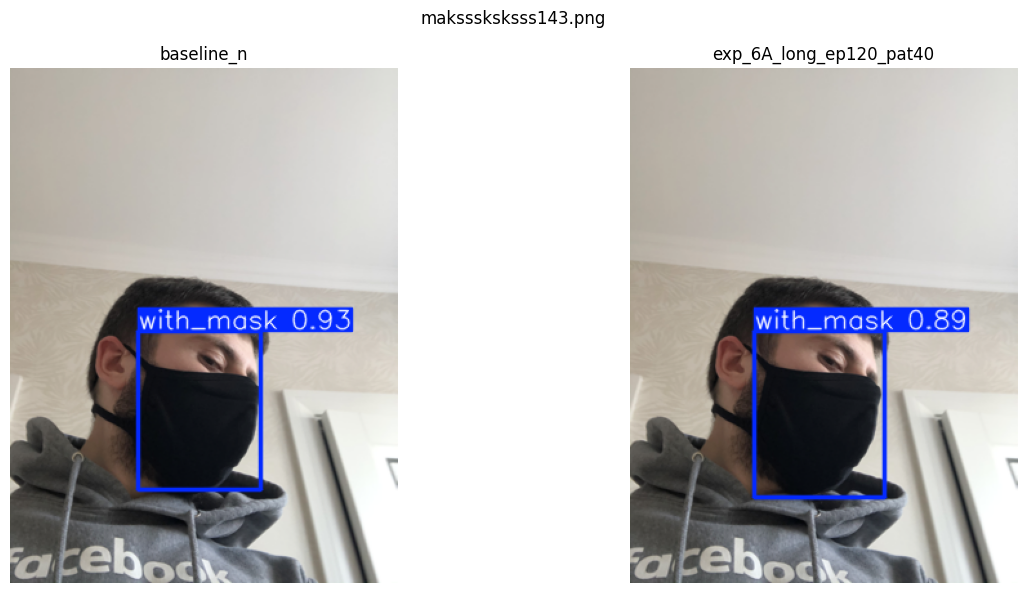

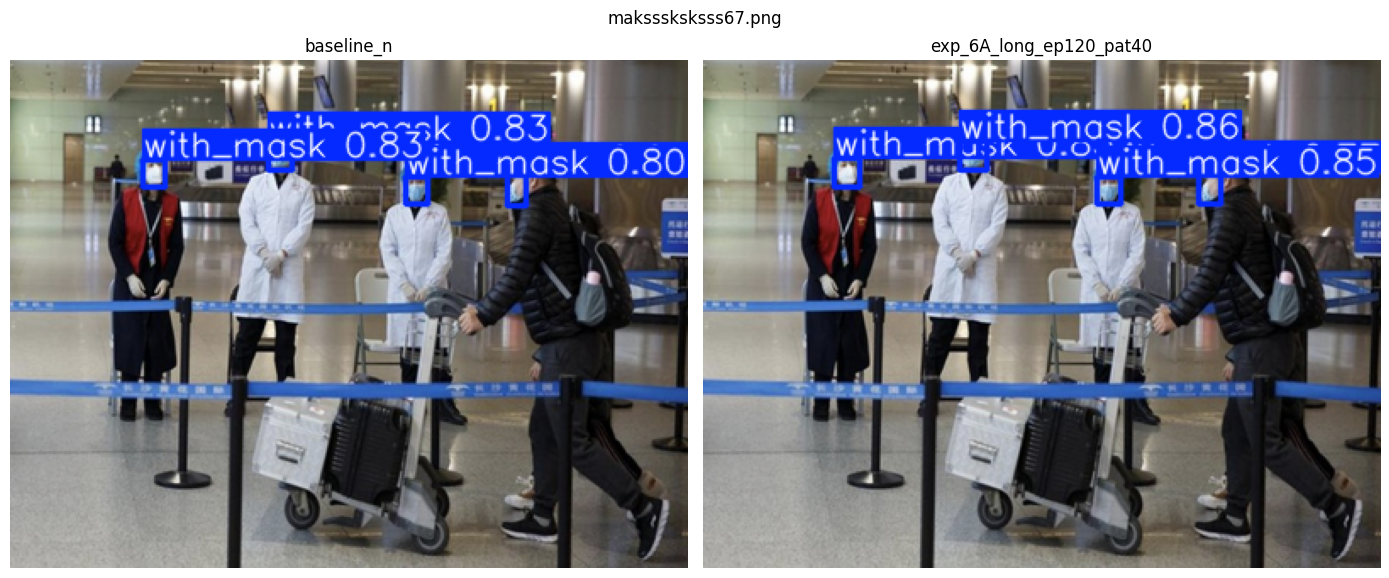

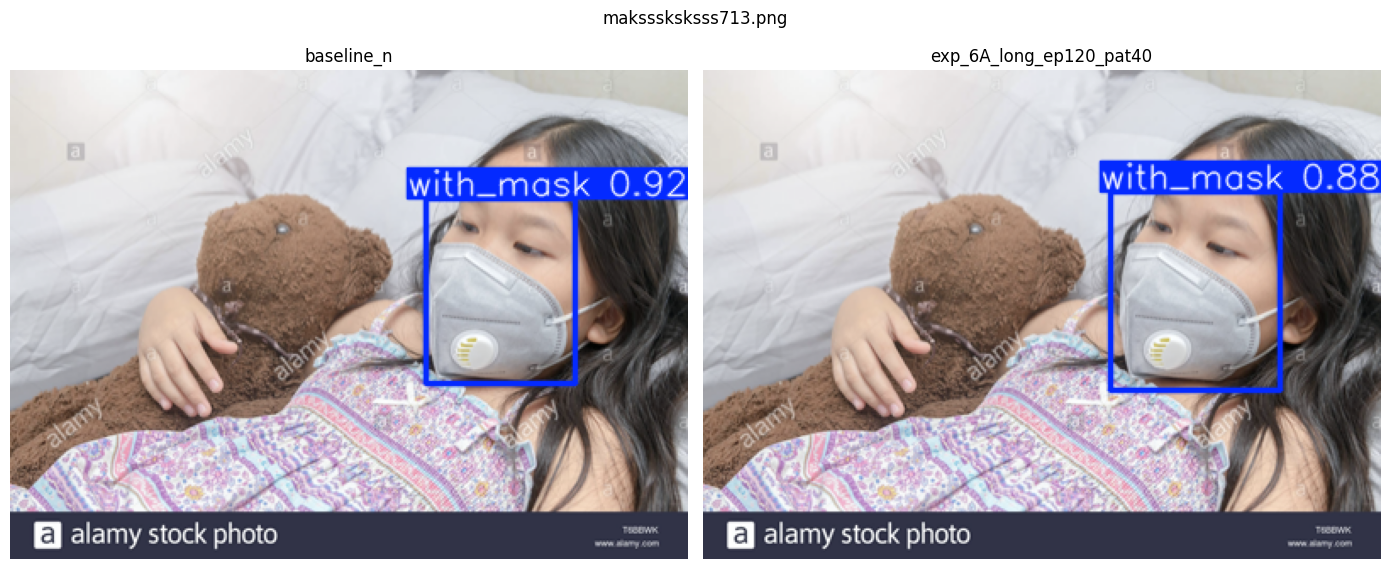

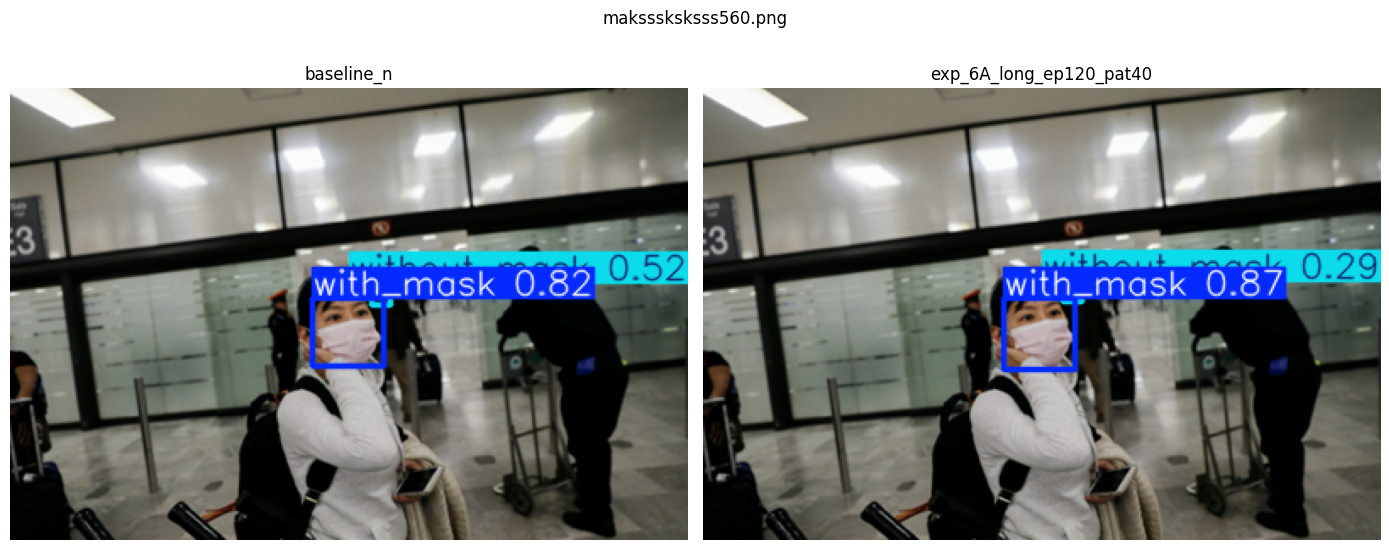

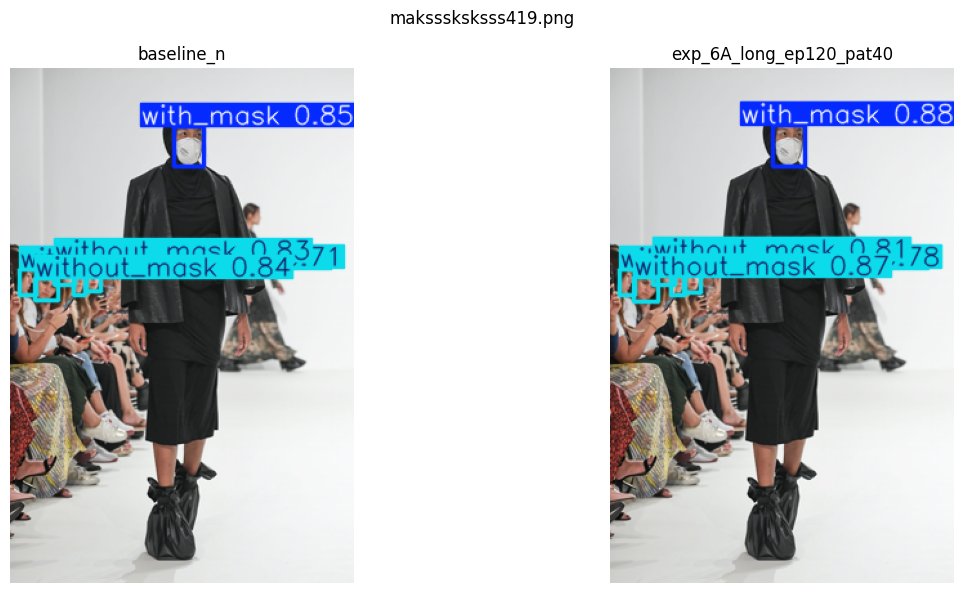

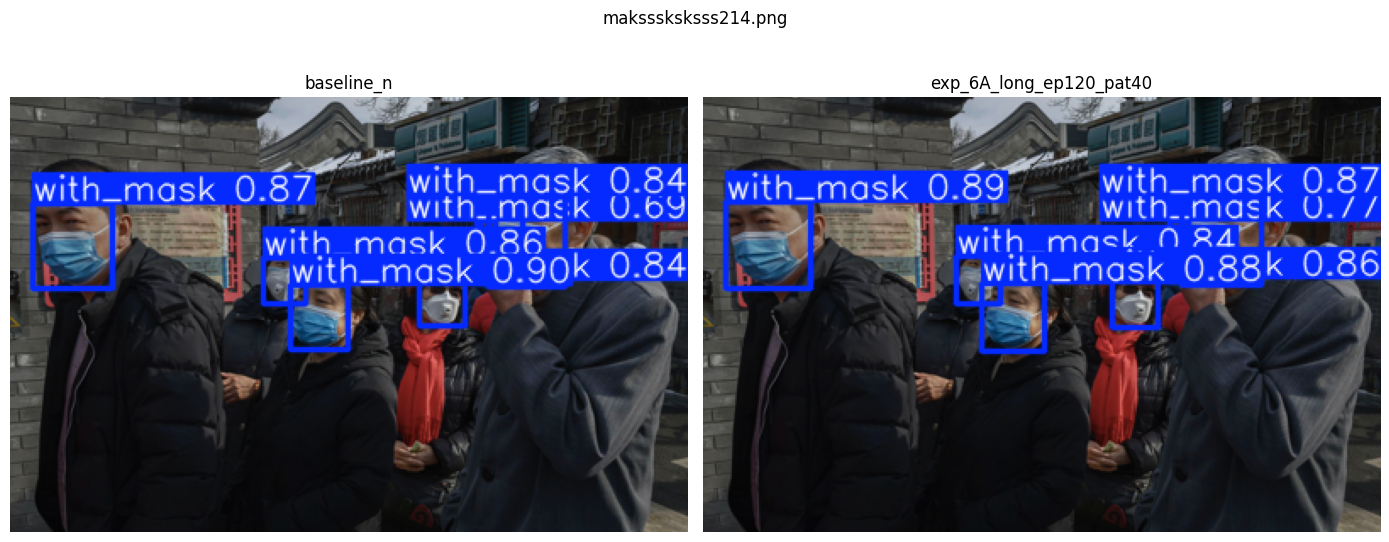

In [4]:
# --- Qualitative comparison: baseline vs best run (val images, predictions overlaid) ---
# Set BEST_RUN to your strongest model by mAP (e.g. exp_6A_long_ep120_pat40). Adjust paths if needed.

from pathlib import Path

import matplotlib.pyplot as plt
from google.colab import drive
from ultralytics import YOLO

drive.mount("/content/drive", force_remount=False)

RUNS_ROOT = Path("/content/drive/MyDrive/CMPE-258-Assignment2/runs")
VAL_IMG_DIR = Path("/content/drive/MyDrive/CMPE-258-Assignment2/mask_yolo/images/val")

BASE_RUN = "baseline_n"
BEST_RUN = "exp_6A_long_ep120_pat40"  # change if you pick another "best"
NUM_IMAGES = 6  # pick a few diverse val images
SEED = 42

baseline = YOLO(str(RUNS_ROOT / BASE_RUN / "weights" / "best.pt"))
best = YOLO(str(RUNS_ROOT / BEST_RUN / "weights" / "best.pt"))

paths = sorted(VAL_IMG_DIR.glob("*"))
paths = [p for p in paths if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}]
rng = __import__("random").Random(SEED)
rng.shuffle(paths)
paths = paths[:NUM_IMAGES]

for p in paths:
    r0 = baseline.predict(source=str(p), imgsz=640, conf=0.25, verbose=False)[0]
    r1 = best.predict(source=str(p), imgsz=640, conf=0.25, verbose=False)[0]
    im0 = r0.plot()[:, :, ::-1]
    im1 = r1.plot()[:, :, ::-1]
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    ax[0].imshow(im0)
    ax[0].set_title(f"{BASE_RUN}")
    ax[0].axis("off")
    ax[1].imshow(im1)
    ax[1].set_title(f"{BEST_RUN}")
    ax[1].axis("off")
    fig.suptitle(p.name)
    plt.tight_layout()
    plt.show()


   run        P        R    mAP50  mAP50-95  mAP50[with_mask]  mAP50[without_mask]  mAP50[mask_weared_incorrect]
         baseline_n 0.900896 0.716876 0.783661  0.545710          0.974931             0.860258                      0.515794
improved_n_strategy 0.810162 0.778122 0.826743  0.559866          0.972169             0.826514                      0.681546
